# NomadOptima — Notebook 02: Perfiles Sintéticos y Pseudo-Labeling

**Objetivo:** Generar 30.000 perfiles sintéticos de usuario y calcular la relevancia  
de cada ciudad para cada perfil usando reglas heurísticas (pseudo-labeling).  
El resultado es un dataset de 60.000 filas listo para entrenar LightGBM.

**Arquetipos:** 8 × 3.750 variaciones = 30.000 perfiles  
**Ciudades:** Málaga, París  
**Output:** `data/processed/training_dataset.csv`

---

## 0. Imports y carga de datos

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'Malaga':   '#2E86AB',
    'Paris':    '#E67E22',
    'Valencia': '#27AE60',
    'Porto':    '#8E44AD',
    'Bordeaux': '#C0392B',
}

# Carga dinámica: lee cities_raw.json (contiene todas las ciudades)
with open('../data/raw/cities_raw.json', encoding='utf-8') as f:
    cities_raw = json.load(f)

print(f'Ciudades cargadas: {list(cities_raw.keys())}')


Ciudades cargadas: ['Malaga', 'Paris', 'Valencia', 'Porto', 'Bordeaux']


---
## 1. Feature store de ciudades

In [2]:
def build_city_store(name, data):
    infra   = data.get('osm', {}).get('infrastructure', {})
    weather = data.get('weather', {}).get('current', {})
    gp      = data.get('google_places', {}).get('categories', {})
    qi      = data.get('numbeo', {}).get('quality_indices', {})
    kp      = data.get('numbeo', {}).get('key_prices', {})
    spd     = data.get('speedtest', {})
    country = data.get('country', {})

    def gp_count(key):
        val = gp.get(key, {})
        return val.get('count', 0) if isinstance(val, dict) else 0

    # Coste de vida: alquiler + utilidades + transporte (datos reales de Numbeo)
    alquiler   = kp.get('rent_1br_center', 0)
    utilities  = kp.get('basic_utilities', 0)
    transport  = kp.get('transport_monthly', 0)
    coste_vida = round(alquiler + utilities + transport, 2)

    return {
        'nombre': name,
        # Coste — datos reales de Numbeo (key_prices fix v9)
        'coste_vida_estimado': coste_vida,
        'alquiler_1br_centro': alquiler,
        'alquiler_1br_fuera':  kp.get('rent_1br_outside', 0),
        'transport_monthly':   transport,
        'basic_utilities':     utilities,
        'meal_cheap':          kp.get('meal_cheap', 0),
        'quality_of_life':     qi.get('Quality of Life Index:', 0),
        # Clima
        'temp_actual_c':    weather.get('temp_c', 0),
        'humedad_pct':      weather.get('humidity_pct', 0),
        'uv_index':         weather.get('uv_index', 0),
        'temp_media_anual': {
            'Malaga': 18.5, 'Paris': 12.3, 'Valencia': 18.0,
            'Porto': 15.5, 'Bordeaux': 13.5
        }.get(name, 15.0),
        'dias_sol_anual': {
            'Malaga': 320, 'Paris': 170, 'Valencia': 310,
            'Porto': 220, 'Bordeaux': 200
        }.get(name, 200),
        # Naturaleza y deporte — conteos reales (offsets geograficos v9)
        'beaches':          infra.get('beaches', 0),
        'parks':            infra.get('parks', 0),
        'gyms':             infra.get('gyms', 0),
        'gp_gym':           gp_count('gym'),
        'gp_marina':        gp_count('marina'),
        'gp_hiking':        gp_count('hiking'),
        'gp_surf_school':   gp_count('surf_school'),
        'gp_cycling_park':  gp_count('cycling_park'),
        'gp_swimming_pool': gp_count('swimming_pool'),
        'gp_yoga_studio':   gp_count('yoga_studio'),
        'gp_sports_club':   gp_count('sports_club'),
        'gp_adventure':     gp_count('adventure_sports'),
        # Gastronomia
        'restaurants':    infra.get('restaurants', 0),
        'cafes':          infra.get('cafes', 0),
        'gp_fine_dining': gp_count('fine_dining'),
        'gp_vegan':       gp_count('vegan_restaurant'),
        'gp_market':      gp_count('market'),
        # Cultura
        'gp_museum':      gp_count('museum'),
        'gp_art_gallery': gp_count('art_gallery'),
        'gp_theater':     gp_count('performing_arts'),
        'gp_cinema':      gp_count('movie_theater'),
        'gp_night_club':  gp_count('night_club'),
        # Nomada digital
        'coworking_osm':          infra.get('coworking_osm', 0),
        'gp_coworking':           gp_count('coworking'),
        'gp_tech_hub':            gp_count('tech_hub'),
        'internet_download_mbps': spd.get('fixed_download_mbps') or 0,  # or 0 maneja None explícito
        # Movilidad
        'public_transport': infra.get('public_transport', 0),
        'bicycle_lanes':    infra.get('bicycle_lanes', 0),
        'bike_parking':     infra.get('bike_parking', 0),
        'gp_subway':        gp_count('subway_station'),
        'gp_train':         gp_count('train_station'),
        # Mascotas
        'dog_areas':    infra.get('dog_areas', 0),
        'gp_dog_park':  gp_count('dog_park'),
        'gp_vet':       gp_count('veterinary_care'),
        # Familia
        'playgrounds':       infra.get('playgrounds', 0),
        'kindergartens':     infra.get('kindergartens', 0),
        'schools':           infra.get('schools', 0),
        'childcare':         infra.get('childcare', 0),
        'pharmacies':        infra.get('pharmacies', 0),
        'hospitals':         infra.get('hospitals', 0),
        'accessible_paths':  infra.get('accessible_paths', 0),
        'gp_playground':     gp_count('playground'),
        'gp_primary_school': gp_count('primary_school'),
        'gp_preschool':      gp_count('preschool'),
        'gp_pediatrician':   gp_count('pediatrician'),
        'gp_pediatric_hosp': gp_count('pediatric_hospital'),
        'gp_intl_school':    gp_count('international_school'),
        'gp_amusement_park': gp_count('amusement_park'),
        'gp_aquarium':       gp_count('aquarium'),
        'gp_zoo':            gp_count('zoo'),
        # Bienestar
        'gp_spa':       gp_count('spa'),
        'gp_wellness':  gp_count('wellness_center'),
        # Pais
        'schengen':          int(country.get('schengen', False)),
        'idioma_espanol':    int('Spanish' in country.get('languages', [])),
        'idioma_frances':    int('French'  in country.get('languages', [])),
        'moneda_eur':        int('EUR' in country.get('currencies', [])),
    }

city_store = {name: build_city_store(name, data) for name, data in cities_raw.items()}
print('Feature store construido')
for name, feat in city_store.items():
    print(f'  {name}: {len(feat)} features')
    kp = cities_raw[name].get('numbeo', {}).get('key_prices', {})
    print(f'    coste_vida_estimado : {feat["coste_vida_estimado"]} EUR/mes')
    print(f'    alquiler_1br_centro : {feat["alquiler_1br_centro"]} EUR/mes')
    print(f'    transport_monthly   : {feat["transport_monthly"]} EUR/mes')
    print(f'    gp_coworking        : {feat["gp_coworking"]} lugares')
    print(f'    gp_museum           : {feat["gp_museum"]} lugares')


Feature store construido
  Malaga: 69 features
    coste_vida_estimado : 1310.23 EUR/mes
    alquiler_1br_centro : 1160.0 EUR/mes
    transport_monthly   : 23.95 EUR/mes
    gp_coworking        : 60 lugares
    gp_museum           : 20 lugares
  Paris: 69 features
    coste_vida_estimado : 1709.92 EUR/mes
    alquiler_1br_centro : 1379.27 EUR/mes
    transport_monthly   : 90.0 EUR/mes
    gp_coworking        : 60 lugares
    gp_museum           : 21 lugares
  Valencia: 69 features
    coste_vida_estimado : 1370.2 EUR/mes
    alquiler_1br_centro : 1198.33 EUR/mes
    transport_monthly   : 30.0 EUR/mes
    gp_coworking        : 60 lugares
    gp_museum           : 20 lugares
  Porto: 69 features
    coste_vida_estimado : 1260.19 EUR/mes
    alquiler_1br_centro : 1099.38 EUR/mes
    transport_monthly   : 40.0 EUR/mes
    gp_coworking        : 60 lugares
    gp_museum           : 20 lugares
  Bordeaux: 69 features
    coste_vida_estimado : 1047.25 EUR/mes
    alquiler_1br_centro : 796.03 E

---
## 2. Definicion de arquetipos

In [3]:
ARQUETIPOS = {
    'nomada_digital': {
        'descripcion': 'Trabaja en remoto, busca coworking y bajo coste',
        'presupuesto_max': 1500, 'temp_min_c': 14,
        'importancia_coworking': 0.90, 'importancia_internet': 0.85,
        'importancia_playa': 0.50, 'importancia_cultura': 0.55,
        'importancia_gastronomia': 0.60, 'importancia_deporte': 0.50,
        'importancia_familia': 0.05, 'importancia_mascotas': 0.20,
        'importancia_movilidad': 0.65, 'importancia_bienestar': 0.45,
        'importancia_vida_noc': 0.40,
        'tiene_mascotas': 0.20, 'tiene_hijos': 0.05, 'necesita_coche': 0.10,
    },
    'familia_con_hijos': {
        'descripcion': 'Familia con ninos, busca seguridad y colegios',
        'presupuesto_max': 2500, 'temp_min_c': 12,
        'importancia_coworking': 0.20, 'importancia_internet': 0.60,
        'importancia_playa': 0.55, 'importancia_cultura': 0.50,
        'importancia_gastronomia': 0.55, 'importancia_deporte': 0.45,
        'importancia_familia': 0.95, 'importancia_mascotas': 0.30,
        'importancia_movilidad': 0.70, 'importancia_bienestar': 0.50,
        'importancia_vida_noc': 0.10,
        'tiene_mascotas': 0.35, 'tiene_hijos': 1.00, 'necesita_coche': 0.60,
    },
    'jubilado_activo': {
        'descripcion': 'Jubilado con movilidad, busca clima calido y calidad de vida',
        'presupuesto_max': 1800, 'temp_min_c': 16,
        'importancia_coworking': 0.05, 'importancia_internet': 0.40,
        'importancia_playa': 0.75, 'importancia_cultura': 0.65,
        'importancia_gastronomia': 0.80, 'importancia_deporte': 0.55,
        'importancia_familia': 0.15, 'importancia_mascotas': 0.40,
        'importancia_movilidad': 0.60, 'importancia_bienestar': 0.80,
        'importancia_vida_noc': 0.20,
        'tiene_mascotas': 0.45, 'tiene_hijos': 0.00, 'necesita_coche': 0.50,
    },
    'estudiante': {
        'descripcion': 'Estudiante universitario, busca bajo coste y vida social',
        'presupuesto_max': 900, 'temp_min_c': 10,
        'importancia_coworking': 0.30, 'importancia_internet': 0.75,
        'importancia_playa': 0.45, 'importancia_cultura': 0.60,
        'importancia_gastronomia': 0.50, 'importancia_deporte': 0.55,
        'importancia_familia': 0.05, 'importancia_mascotas': 0.10,
        'importancia_movilidad': 0.80, 'importancia_bienestar': 0.30,
        'importancia_vida_noc': 0.85,
        'tiene_mascotas': 0.05, 'tiene_hijos': 0.00, 'necesita_coche': 0.05,
    },
    'ejecutivo_cosmopolita': {
        'descripcion': 'Ejecutivo con alto poder adquisitivo, cultura y gastronomia premium',
        'presupuesto_max': 4000, 'temp_min_c': 8,
        'importancia_coworking': 0.50, 'importancia_internet': 0.80,
        'importancia_playa': 0.25, 'importancia_cultura': 0.85,
        'importancia_gastronomia': 0.90, 'importancia_deporte': 0.45,
        'importancia_familia': 0.30, 'importancia_mascotas': 0.15,
        'importancia_movilidad': 0.75, 'importancia_bienestar': 0.65,
        'importancia_vida_noc': 0.60,
        'tiene_mascotas': 0.15, 'tiene_hijos': 0.30, 'necesita_coche': 0.40,
    },
    'deportista_outdoor': {
        'descripcion': 'Kitesurf, surf, senderismo, ciclismo',
        'presupuesto_max': 1600, 'temp_min_c': 15,
        'importancia_coworking': 0.30, 'importancia_internet': 0.50,
        'importancia_playa': 0.90, 'importancia_cultura': 0.30,
        'importancia_gastronomia': 0.55, 'importancia_deporte': 0.95,
        'importancia_familia': 0.10, 'importancia_mascotas': 0.25,
        'importancia_movilidad': 0.50, 'importancia_bienestar': 0.60,
        'importancia_vida_noc': 0.35,
        'tiene_mascotas': 0.20, 'tiene_hijos': 0.05, 'necesita_coche': 0.35,
    },
    'backpacker': {
        'descripcion': 'Viajero de bajo coste, autenticidad y comunidad',
        'presupuesto_max': 700, 'temp_min_c': 12,
        'importancia_coworking': 0.35, 'importancia_internet': 0.60,
        'importancia_playa': 0.60, 'importancia_cultura': 0.70,
        'importancia_gastronomia': 0.65, 'importancia_deporte': 0.50,
        'importancia_familia': 0.05, 'importancia_mascotas': 0.10,
        'importancia_movilidad': 0.85, 'importancia_bienestar': 0.25,
        'importancia_vida_noc': 0.70,
        'tiene_mascotas': 0.05, 'tiene_hijos': 0.00, 'necesita_coche': 0.05,
    },
    'familia_monoparental': {
        'descripcion': 'Padre/madre solo con hijos, bajo coste y guarderia accesible',
        'presupuesto_max': 1100, 'temp_min_c': 13,
        'importancia_coworking': 0.40, 'importancia_internet': 0.65,
        'importancia_playa': 0.50, 'importancia_cultura': 0.40,
        'importancia_gastronomia': 0.45, 'importancia_deporte': 0.35,
        'importancia_familia': 0.95, 'importancia_mascotas': 0.20,
        'importancia_movilidad': 0.85, 'importancia_bienestar': 0.45,
        'importancia_vida_noc': 0.05,
        'tiene_mascotas': 0.20, 'tiene_hijos': 1.00, 'necesita_coche': 0.30,
    },
}

print(f'Arquetipos definidos: {len(ARQUETIPOS)}')
for nombre, arq in ARQUETIPOS.items():
    print(f'  {nombre:<25} — {arq["descripcion"]}')

Arquetipos definidos: 8
  nomada_digital            — Trabaja en remoto, busca coworking y bajo coste
  familia_con_hijos         — Familia con ninos, busca seguridad y colegios
  jubilado_activo           — Jubilado con movilidad, busca clima calido y calidad de vida
  estudiante                — Estudiante universitario, busca bajo coste y vida social
  ejecutivo_cosmopolita     — Ejecutivo con alto poder adquisitivo, cultura y gastronomia premium
  deportista_outdoor        — Kitesurf, surf, senderismo, ciclismo
  backpacker                — Viajero de bajo coste, autenticidad y comunidad
  familia_monoparental      — Padre/madre solo con hijos, bajo coste y guarderia accesible


---
## 3. Generador de perfiles con ruido gaussiano

In [4]:
N_PER_ARCHETYPE = 3750  # 8 x 3750 = 30.000 perfiles

NOISE = {
    'presupuesto_max': 200, 'temp_min_c': 2.5,
    'importancia_coworking': 0.12, 'importancia_internet': 0.10,
    'importancia_playa': 0.15, 'importancia_cultura': 0.15,
    'importancia_gastronomia': 0.13, 'importancia_deporte': 0.15,
    'importancia_familia': 0.08, 'importancia_mascotas': 0.10,
    'importancia_movilidad': 0.12, 'importancia_bienestar': 0.12,
    'importancia_vida_noc': 0.15,
}

def generate_profiles(archetype_name, archetype_def, n):
    profiles = []
    for i in range(n):
        p = {'arquetipo': archetype_name, 'perfil_id': f'{archetype_name}_{i:04d}'}
        for key, std in NOISE.items():
            valor = np.random.normal(archetype_def[key], std)
            if key.startswith('importancia_'):
                valor = float(np.clip(valor, 0.0, 1.0))
            elif key == 'presupuesto_max':
                valor = max(300.0, valor)
            p[key] = round(valor, 4)
        p['tiene_mascotas'] = int(np.random.random() < archetype_def['tiene_mascotas'])
        p['tiene_hijos']    = int(np.random.random() < archetype_def['tiene_hijos'])
        p['necesita_coche'] = int(np.random.random() < archetype_def['necesita_coche'])
        profiles.append(p)
    return profiles

all_profiles = []
for nombre, arq in ARQUETIPOS.items():
    perfiles = generate_profiles(nombre, arq, N_PER_ARCHETYPE)
    all_profiles.extend(perfiles)
    print(f'  {nombre:<25} {len(perfiles):,} perfiles')

df_profiles = pd.DataFrame(all_profiles)
print(f'\nTotal: {len(df_profiles):,} perfiles — shape {df_profiles.shape}')

  nomada_digital            3,750 perfiles


  familia_con_hijos         3,750 perfiles


  jubilado_activo           3,750 perfiles


  estudiante                3,750 perfiles


  ejecutivo_cosmopolita     3,750 perfiles


  deportista_outdoor        3,750 perfiles


  backpacker                3,750 perfiles


  familia_monoparental      3,750 perfiles

Total: 30,000 perfiles — shape (30000, 18)


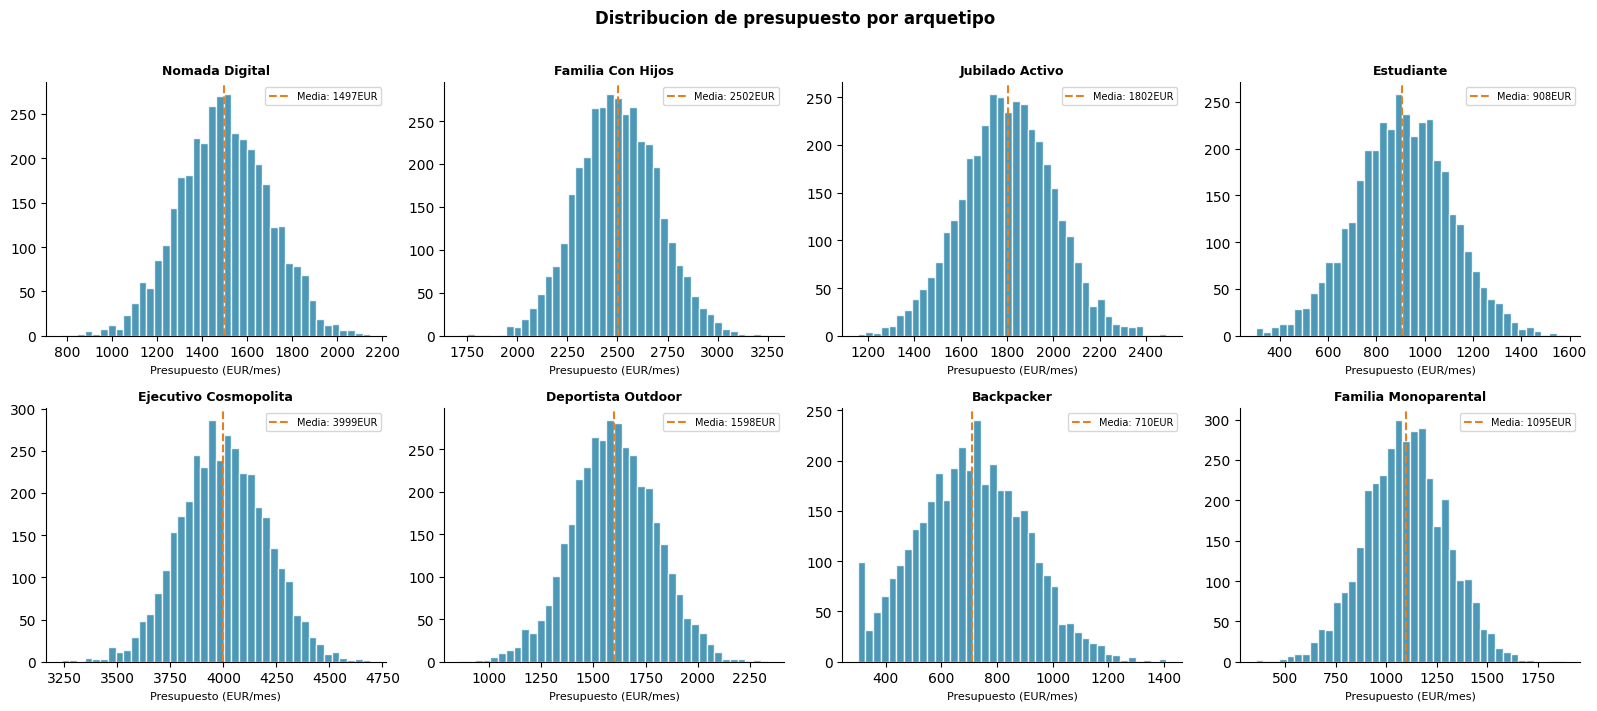

In [5]:
# Distribucion de presupuesto por arquetipo
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for idx, (nombre, ax) in enumerate(zip(ARQUETIPOS.keys(), axes)):
    subset = df_profiles[df_profiles['arquetipo'] == nombre]['presupuesto_max']
    ax.hist(subset, bins=40, color='#2E86AB', edgecolor='white', alpha=0.85)
    ax.set_title(nombre.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.set_xlabel('Presupuesto (EUR/mes)', fontsize=8)
    ax.axvline(subset.mean(), color='#E67E22', linestyle='--', linewidth=1.5,
               label=f'Media: {subset.mean():.0f}EUR')
    ax.legend(fontsize=7)
plt.suptitle('Distribucion de presupuesto por arquetipo', fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/profiles_budget_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Sistema de pseudo-labeling

In [6]:
def compute_relevance(perfil, ciudad):
    score = 0.0

    # Restricciones duras
    if ciudad['coste_vida_estimado'] > perfil['presupuesto_max'] * 1.15:
        return 0
    if ciudad['temp_media_anual'] < perfil['temp_min_c'] - 3:
        return 0

    # Coste de vida
    ratio = ciudad['coste_vida_estimado'] / max(perfil['presupuesto_max'], 1)
    if   ratio < 0.60: score += 2.0
    elif ratio < 0.80: score += 1.5
    elif ratio < 1.00: score += 0.8

    # Clima
    score += min((ciudad['temp_media_anual'] - perfil['temp_min_c']) / 10.0, 1.5)
    score += (ciudad['dias_sol_anual'] / 365.0) * 1.0

    # Playa
    if perfil['importancia_playa'] > 0.5:
        score += min(ciudad['beaches'] / 10.0, 1.0) * perfil['importancia_playa'] * 2

    # Deporte outdoor
    if perfil['importancia_deporte'] > 0.4:
        ds = (min(ciudad['gyms'] / 50, 1.0) * 0.3 +
              min(ciudad['gp_surf_school'] / 2, 1.0) * 0.4 +
              min(ciudad['gp_marina'] / 5, 1.0) * 0.3)
        score += ds * perfil['importancia_deporte'] * 2

    # Nomada digital
    if perfil['importancia_coworking'] > 0.4:
        cw = ciudad['coworking_osm'] + ciudad['gp_coworking']
        score += min(cw / 20, 1.0) * perfil['importancia_coworking'] * 2
    if perfil['importancia_internet'] > 0.4:
        score += min(ciudad['internet_download_mbps'] / 200, 1.0) * perfil['importancia_internet']

    # Cultura
    if perfil['importancia_cultura'] > 0.4:
        cs = (min(ciudad['gp_museum'] / 10, 1.0) * 0.4 +
              min(ciudad['gp_theater'] / 5, 1.0) * 0.3 +
              min(ciudad['gp_art_gallery'] / 10, 1.0) * 0.3)
        score += cs * perfil['importancia_cultura'] * 2

    # Gastronomia
    if perfil['importancia_gastronomia'] > 0.4:
        gs = (min(ciudad['restaurants'] / 500, 1.0) * 0.4 +
              min(ciudad['gp_fine_dining'] / 10, 1.0) * 0.35 +
              min(ciudad['gp_market'] / 10, 1.0) * 0.25)
        score += gs * perfil['importancia_gastronomia'] * 1.5

    # Movilidad
    if perfil['importancia_movilidad'] > 0.4 and not perfil['necesita_coche']:
        ms = (min(ciudad['public_transport'] / 2000, 1.0) * 0.5 +
              min(ciudad['bicycle_lanes'] / 1000, 1.0) * 0.3 +
              min(ciudad['gp_subway'] / 10, 1.0) * 0.2)
        score += ms * perfil['importancia_movilidad'] * 1.5

    # Familia
    if perfil['importancia_familia'] > 0.5 or perfil['tiene_hijos']:
        fs = (min(ciudad['playgrounds'] / 50, 1.0) * 0.20 +
              min(ciudad['kindergartens'] / 50, 1.0) * 0.20 +
              min(ciudad['schools'] / 200, 1.0) * 0.15 +
              min(ciudad['pharmacies'] / 100, 1.0) * 0.15 +
              min(ciudad['hospitals'] / 5, 1.0) * 0.15 +
              min(ciudad['gp_pediatrician'] / 10, 1.0) * 0.15)
        score += fs * perfil['importancia_familia'] * 2.5

    # Mascotas
    if perfil['tiene_mascotas']:
        ms = (min(ciudad['dog_areas'] / 5, 1.0) * 0.4 +
              min(ciudad['gp_vet'] / 10, 1.0) * 0.4 +
              min(ciudad['gp_dog_park'] / 5, 1.0) * 0.2)
        score += ms * perfil['importancia_mascotas'] * 1.5

    # Bienestar
    if perfil['importancia_bienestar'] > 0.4:
        bs = (min(ciudad['gp_spa'] / 10, 1.0) * 0.5 +
              min(ciudad['gp_wellness'] / 5, 1.0) * 0.3 +
              min(ciudad['gp_yoga_studio'] / 5, 1.0) * 0.2)
        score += bs * perfil['importancia_bienestar'] * 1.5

    # Vida nocturna
    if perfil['importancia_vida_noc'] > 0.5:
        score += min(ciudad['gp_night_club'] / 10, 1.0) * perfil['importancia_vida_noc']

    # Convertir a escala 0-3
    return int(np.clip(round(score / 15.0 * 3.0), 0, 3))


# Test rapido
print('=== TEST DE RELEVANCIA ===')
perfil_test = df_profiles[df_profiles['arquetipo'] == 'nomada_digital'].iloc[0].to_dict()
print(f'Nomada digital: presupuesto={perfil_test["presupuesto_max"]:.0f}EUR, temp_min={perfil_test["temp_min_c"]:.1f}C')
for city_name, city_feat in city_store.items():
    rel = compute_relevance(perfil_test, city_feat)
    print(f'  {city_name}: relevancia = {rel} {"*" * rel}')

=== TEST DE RELEVANCIA ===
Nomada digital: presupuesto=1599EUR, temp_min=13.7C
  Malaga: relevancia = 2 **
  Paris: relevancia = 2 **
  Valencia: relevancia = 2 **
  Porto: relevancia = 1 *
  Bordeaux: relevancia = 2 **


---
## 5. Construccion del dataset de entrenamiento

In [7]:
print('Construyendo dataset de entrenamiento...')
training_rows = []

for _, perfil_row in df_profiles.iterrows():
    perfil = perfil_row.to_dict()
    for city_name, city_feat in city_store.items():
        relevance = compute_relevance(perfil, city_feat)
        row = {
            'query_id':  perfil['perfil_id'],
            'city':      city_name,
            'arquetipo': perfil['arquetipo'],
            'relevance': relevance,
            **{f'user_{k}': v for k, v in perfil.items() if k not in ['perfil_id', 'arquetipo']},
            **{f'city_{k}': v for k, v in city_feat.items() if k != 'nombre'},
        }
        training_rows.append(row)

df_train = pd.DataFrame(training_rows)
df_train.to_csv('../data/processed/training_dataset.csv', index=False)
print(f'Shape: {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas')
print('Guardado: data/processed/training_dataset.csv')

Construyendo dataset de entrenamiento...


Shape: 150,000 filas x 88 columnas
Guardado: data/processed/training_dataset.csv


In [8]:
# Distribucion de relevancia por ciudad y arquetipo
print('=== DISTRIBUCION DE RELEVANCIA POR CIUDAD ===')
pivot = df_train.groupby(['city', 'relevance']).size().unstack(fill_value=0)
print(pivot.to_string())

print('\n=== RELEVANCIA MEDIA POR ARQUETIPO Y CIUDAD ===')
pivot2 = df_train.groupby(['arquetipo', 'city'])['relevance'].mean().unstack().round(2)
print(pivot2.to_string())

=== DISTRIBUCION DE RELEVANCIA POR CIUDAD ===
relevance      0      1      2    3
city                               
Bordeaux    9439   9575  10973   13
Malaga      9468   2750  17533  249
Paris      18581   3623   7656  140
Porto      10004  15755   4241    0
Valencia   10247  12117   7636    0

=== RELEVANCIA MEDIA POR ARQUETIPO Y CIUDAD ===
city                   Bordeaux  Malaga  Paris  Porto  Valencia
arquetipo                                                      
backpacker                 0.16    0.03   0.00   0.03      0.01
deportista_outdoor         0.83    1.74   0.42   0.91      1.01
ejecutivo_cosmopolita      2.00    2.06   2.03   1.93      2.00
estudiante                 0.55    0.17   0.00   0.17      0.07
familia_con_hijos          1.65    1.95   1.67   1.02      1.32
familia_monoparental       0.88    0.59   0.03   0.45      0.31
jubilado_activo            0.88    1.92   0.46   0.87      1.13
nomada_digital             1.47    1.83   0.56   1.09      1.45


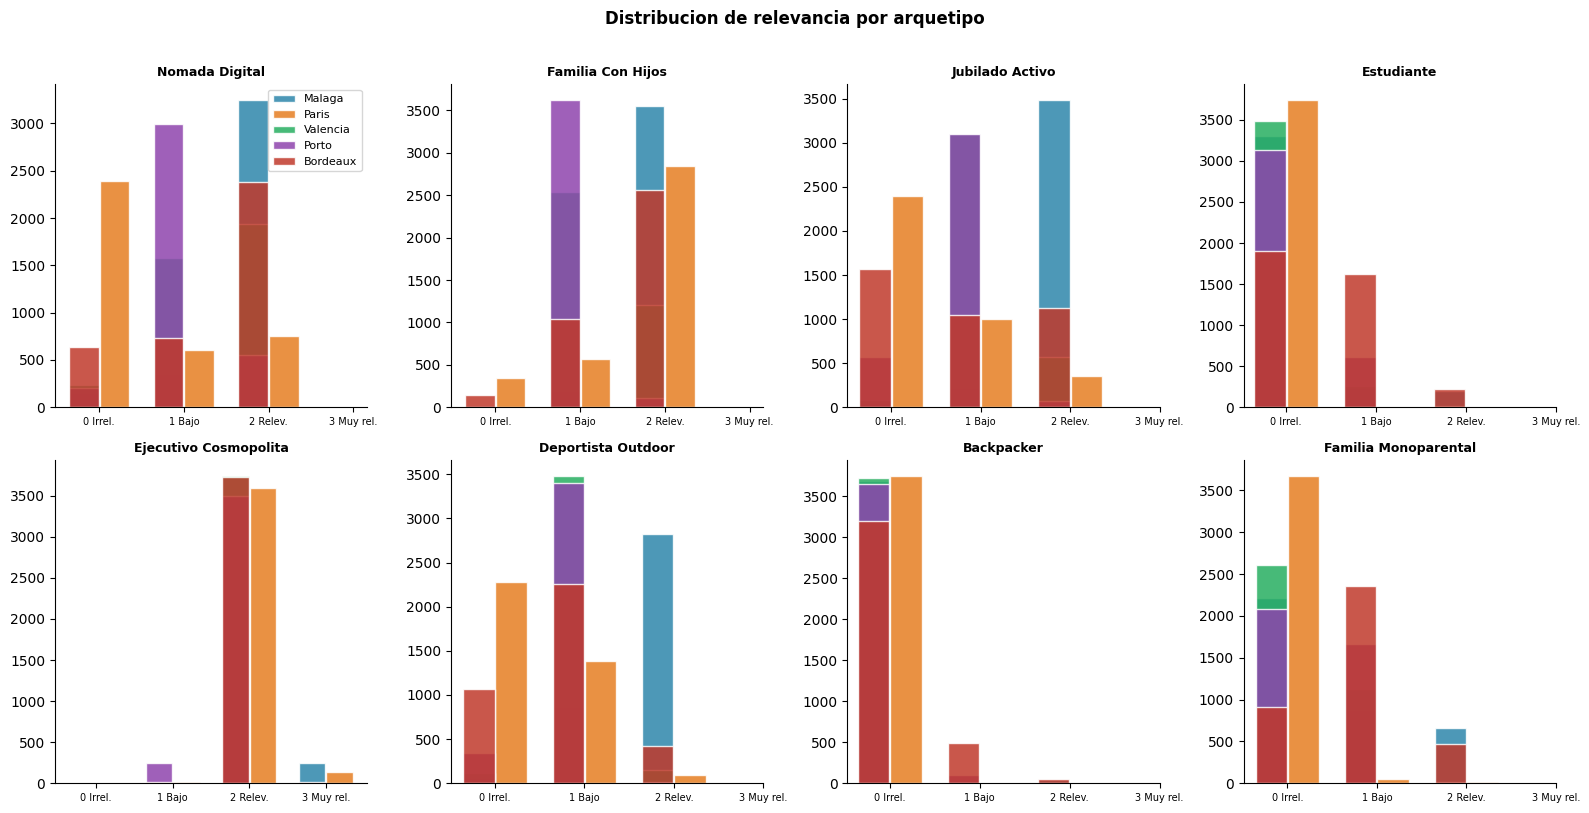

In [9]:
# Visualizacion distribucion de relevancia
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for idx, (arq, ax) in enumerate(zip(ARQUETIPOS.keys(), axes)):
    subset = df_train[df_train['arquetipo'] == arq]
    for city_name, color in COLORS.items():
        city_sub = subset[subset['city'] == city_name]
        counts = city_sub['relevance'].value_counts().sort_index()
        offset = 0.18 if city_name == 'Paris' else -0.18
        ax.bar([x + offset for x in counts.index], counts.values,
               width=0.35, label=city_name, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(arq.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0 Irrel.', '1 Bajo', '2 Relev.', '3 Muy rel.'], fontsize=7)
    if idx == 0: ax.legend(fontsize=8)
plt.suptitle('Distribucion de relevancia por arquetipo', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/relevance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Validacion del pseudo-labeling

In [10]:
print('=== VALIDACION DE COHERENCIA GEOGRAFICA ===')
checks = [
    ('nomada_digital',       'Malaga', 'Paris',  'Nomada prefiere Malaga (mas barata y calida)'),
    ('ejecutivo_cosmopolita','Paris',  'Malaga',  'Ejecutivo prefiere Paris (cultura y gastronomia premium)'),
    ('deportista_outdoor',   'Malaga', 'Paris',  'Deportista prefiere Malaga (playa, surf)'),
    ('estudiante',           'Malaga', 'Paris',  'Estudiante prefiere Malaga (mas barata)'),
    ('backpacker',           'Malaga', 'Paris',  'Backpacker prefiere Malaga (bajo coste)'),
    ('jubilado_activo',      'Malaga', 'Paris',  'Jubilado prefiere Malaga (clima, calidad de vida)'),
    ('familia_con_hijos',    'Paris',  'Malaga', 'Familia con hijos puede preferir Paris (mas colegios, hospitales)'),
    ('familia_monoparental', 'Malaga', 'Paris',  'Familia monoparental prefiere Malaga (bajo coste)'),
]

all_ok = True
for arq, city_a, city_b, desc in checks:
    subset = df_train[df_train['arquetipo'] == arq]
    media_a = subset[subset['city'] == city_a]['relevance'].mean()
    media_b = subset[subset['city'] == city_b]['relevance'].mean()
    ok = media_a >= media_b
    all_ok = all_ok and ok
    status = 'OK' if ok else 'REVISAR'
    print(f'[{status}] {desc}')
    print(f'       {city_a}: {media_a:.2f}  vs  {city_b}: {media_b:.2f}')

print()
print('RESULTADO:', 'Pseudo-labeling coherente' if all_ok else 'Algunas reglas necesitan revision')

=== VALIDACION DE COHERENCIA GEOGRAFICA ===
[OK] Nomada prefiere Malaga (mas barata y calida)
       Malaga: 1.83  vs  Paris: 0.56
[REVISAR] Ejecutivo prefiere Paris (cultura y gastronomia premium)
       Paris: 2.03  vs  Malaga: 2.06
[OK] Deportista prefiere Malaga (playa, surf)
       Malaga: 1.74  vs  Paris: 0.42
[OK] Estudiante prefiere Malaga (mas barata)
       Malaga: 0.17  vs  Paris: 0.00
[OK] Backpacker prefiere Malaga (bajo coste)
       Malaga: 0.03  vs  Paris: 0.00
[OK] Jubilado prefiere Malaga (clima, calidad de vida)
       Malaga: 1.92  vs  Paris: 0.46
[REVISAR] Familia con hijos puede preferir Paris (mas colegios, hospitales)
       Paris: 1.67  vs  Malaga: 1.95
[OK] Familia monoparental prefiere Malaga (bajo coste)
       Malaga: 0.59  vs  Paris: 0.03

RESULTADO: Algunas reglas necesitan revision


In [11]:
# Resumen final
print('=' * 55)
print('RESUMEN DEL DATASET DE ENTRENAMIENTO')
print('=' * 55)
print(f'Filas totales   : {len(df_train):,}')
print(f'Columnas        : {df_train.shape[1]}')
print(f'Perfiles unicos : {df_train["query_id"].nunique():,}')
print(f'Ciudades        : {df_train["city"].nunique()}')
print(f'Arquetipos      : {df_train["arquetipo"].nunique()}')
print()
print('Distribucion de relevancia:')
names = {0: 'Irrelevante', 1: 'Bajo', 2: 'Relevante', 3: 'Muy relevante'}
for label, count in df_train['relevance'].value_counts().sort_index().items():
    pct = count / len(df_train) * 100
    print(f'  {label} {names[label]:<14}: {count:>7,} ({pct:>5.1f}%) {"#" * int(pct/2)}')
print()
nan_total = df_train.isna().sum().sum()
print(f'NaN totales: {nan_total} ({"Limpio" if nan_total == 0 else "Revisar"})')
print('=' * 55)
print('Siguiente paso: notebook 03_lightgbm_ranker.ipynb')

RESUMEN DEL DATASET DE ENTRENAMIENTO
Filas totales   : 150,000
Columnas        : 88
Perfiles unicos : 30,000
Ciudades        : 5
Arquetipos      : 8

Distribucion de relevancia:
  0 Irrelevante   :  57,739 ( 38.5%) ###################
  1 Bajo          :  43,820 ( 29.2%) ##############
  2 Relevante     :  48,039 ( 32.0%) ################
  3 Muy relevante :     402 (  0.3%) 

NaN totales: 0 (Limpio)
Siguiente paso: notebook 03_lightgbm_ranker.ipynb
